# IFN680 Assessment 3 - Aircraft Classification (Development Notebook)

**Student 1:** Karan Rooprai  **Student ID:** N12498122

**Student 2:** Nhu Hieu Nguyen  **Student ID:** N12194778


In [1]:
import os
import copy
import random
import pickle

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset


SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda:0


## Data

### To remove ipynb checkpoints

In [2]:
DATA_ROOT = 'FGVCAircraft_Subset20'

for root, dirs, files in os.walk(DATA_ROOT):
    for d in list(dirs):
        if d == '.ipynb_checkpoints':
            import shutil
            shutil.rmtree(os.path.join(root, d))
            print('Removed', os.path.join(root, d))
print('Checkpoints Removed!')

Checkpoints Removed!


Classes (20): ['class_00', 'class_01', 'class_02', 'class_03', 'class_04', 'class_05', 'class_06', 'class_07', 'class_08', 'class_09', 'class_10', 'class_11', 'class_12', 'class_13', 'class_14', 'class_15', 'class_16', 'class_17', 'class_18', 'class_19']
Trainval dataset size: 1331
Test dataset size:     669


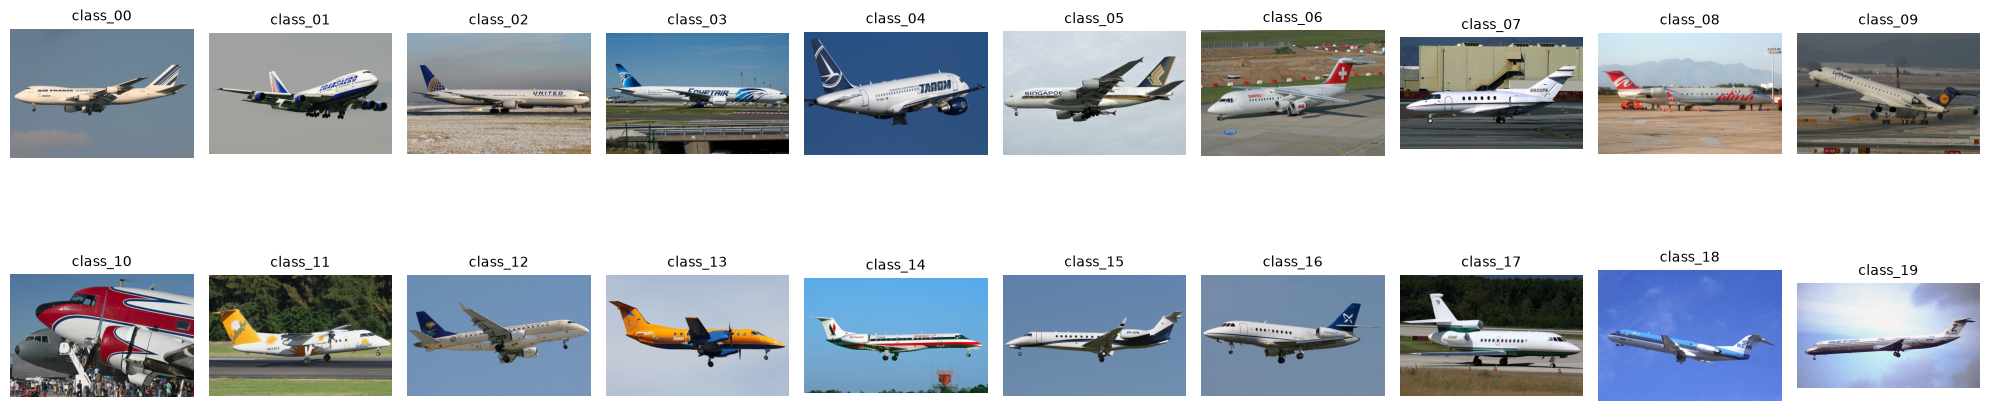

In [3]:
# Loading without transforms 
trainval_dataset = torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, 'trainval'))
test_dataset     = torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, 'test'))

class_names = trainval_dataset.classes
num_classes = len(class_names)

print(f'Classes ({num_classes}): {class_names}')
print(f'Trainval dataset size: {len(trainval_dataset)}')
print(f'Test dataset size:     {len(test_dataset)}')


fig, axes = plt.subplots(2, 10, figsize=(20, 6))


class_names = trainval_dataset.classes
dataset_labels = np.array([label for _, label in trainval_dataset.samples])


for class_idx in range(num_classes):
    class_indices = np.where(dataset_labels == class_idx)[0] 
    
    
    sample_idx = np.random.choice(class_indices)
    
    
    img, _ = trainval_dataset[sample_idx]

    row, col = int(class_idx // 10), int(class_idx % 10)
    axes[row, col].imshow(img)
    axes[row, col].set_title(class_names[class_idx].split('-')[-1], fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Data Split 

In [4]:
indices = list(range(len(trainval_dataset)))
labels  = [label for _, label in trainval_dataset.samples]

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,     
    random_state=42,
)
print(f'Train samples: {len(train_indices)}   Val samples: {len(val_indices)}')

Train samples: 1064   Val samples: 267


### Preprocessing and augmentation transforms

Every image is resized to 224×224 and normalised with the ImageNet mean/std

In [5]:
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds  = (0.229, 0.224, 0.225)


eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(imagenet_means, imagenet_stds),
])

# With augmentation (only for training)
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(imagenet_means, imagenet_stds),
])

### DataLoader helper

In [6]:
BATCH_SIZE = 32

def make_loaders(train_transform, full_trainval=False):
    base = torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, 'trainval'))

    if full_trainval:
        train_ds = copy.deepcopy(base)
        train_ds.transform = train_transform
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        return train_loader, None

    train_ds = copy.deepcopy(base); train_ds.transform = train_transform
    val_ds   = copy.deepcopy(base); val_ds.transform   = eval_transform
    train_loader = DataLoader(Subset(train_ds, train_indices), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(Subset(val_ds,   val_indices),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return train_loader, val_loader

## Model and training helpers

In [7]:
def setup_model(model, num_classes, freeze_backbone=False):
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():  
            param.requires_grad = True
    return model

In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        predicted = torch.argmax(outputs, axis=1)
        correct += (predicted == targets).sum().item()
        total   += targets.size(0)
    return running_loss / total, correct / total




In [9]:
def eval_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            predicted = torch.argmax(outputs, axis=1)
            correct += (predicted == targets).sum().item()
            total   += targets.size(0)
    return running_loss / total, correct / total

In [10]:
def run_training(model, train_loader, val_loader, optimizer, criterion,
                 epochs, scheduler=None, save_path=None):
     # Training for 'epochs', recording learning curves. Returns (history, best_val_acc)
    model = model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state = -1.0, None

    for epoch in range(epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)

        if val_loader is not None:
            va_loss, va_acc = eval_epoch(model, val_loader, criterion, device)
            history['val_loss'].append(va_loss)
            history['val_acc'].append(va_acc)
            if va_acc > best_val_acc:
                best_val_acc = va_acc
                best_state = copy.deepcopy(model.state_dict())
            print(f'Epoch {epoch+1:2d}/{epochs} | '
                  f'train loss {tr_loss:.3f} acc {tr_acc:.3f} | '
                  f'val loss {va_loss:.3f} acc {va_acc:.3f}')
        else:
            print(f'Epoch {epoch+1:2d}/{epochs} | train loss {tr_loss:.3f} acc {tr_acc:.3f}')

        if scheduler is not None:
            scheduler.step()


    if best_state is None:
        best_state = copy.deepcopy(model.state_dict())
    if save_path is not None:
        torch.save(best_state, save_path)
        print(f'Saved weights -> {save_path}')

    history['best_val_acc'] = best_val_acc
    return history, best_val_acc

In [11]:
# Collecting every  history here so we can reload and plot them in main
histories = {}
criterion = nn.CrossEntropyLoss()
EPOCHS = 12   # epochs per baseline/experiment run

# Baseline -> frozen ResNet-18 feature extractor

ResNet-18 is loaded with ImageNet weights, the backbone is **frozen**, and
only the new 20-way head is trained with plain SGD (lr = 0.001, momentum = 0.9) on
**un-augmented** images.

In [12]:
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
baseline_model = setup_model(backbone, num_classes, freeze_backbone=True)

train_loader, val_loader = make_loaders(eval_transform)   # no augmentation
optimizer = optim.SGD(filter(lambda p: p.requires_grad, baseline_model.parameters()),
                      lr=0.001, momentum=0.9)

histories['baseline'], _ = run_training(
    baseline_model, train_loader, val_loader, optimizer, criterion, epochs=EPOCHS)

Epoch  1/12 | train loss 3.033 acc 0.073 | val loss 2.922 acc 0.097
Epoch  2/12 | train loss 2.785 acc 0.171 | val loss 2.732 acc 0.199
Epoch  3/12 | train loss 2.548 acc 0.291 | val loss 2.588 acc 0.255
Epoch  4/12 | train loss 2.356 acc 0.418 | val loss 2.460 acc 0.322
Epoch  5/12 | train loss 2.213 acc 0.454 | val loss 2.346 acc 0.375
Epoch  6/12 | train loss 2.054 acc 0.519 | val loss 2.248 acc 0.401
Epoch  7/12 | train loss 1.937 acc 0.575 | val loss 2.170 acc 0.412
Epoch  8/12 | train loss 1.820 acc 0.605 | val loss 2.095 acc 0.434
Epoch  9/12 | train loss 1.741 acc 0.644 | val loss 2.038 acc 0.468
Epoch 10/12 | train loss 1.634 acc 0.671 | val loss 1.997 acc 0.487
Epoch 11/12 | train loss 1.562 acc 0.683 | val loss 1.942 acc 0.491
Epoch 12/12 | train loss 1.491 acc 0.700 | val loss 1.907 acc 0.509


## Experiment 1 -> Data augmentation

The only difference is the training transform, 'aug_transform' instead of 'eval_transform'.  The Architecture, freezing, optimiser and epochs remains unchanged.

In [13]:
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
aug_model = setup_model(backbone, num_classes, freeze_backbone=True)

train_loader, val_loader = make_loaders(aug_transform)    # augmentation ON
optimizer = optim.SGD(filter(lambda p: p.requires_grad, aug_model.parameters()),
                      lr=0.001, momentum=0.9)

histories['aug'], _ = run_training(
    aug_model, train_loader, val_loader, optimizer, criterion, epochs=EPOCHS)

Epoch  1/12 | train loss 3.035 acc 0.060 | val loss 2.981 acc 0.090
Epoch  2/12 | train loss 2.878 acc 0.117 | val loss 2.853 acc 0.157
Epoch  3/12 | train loss 2.703 acc 0.217 | val loss 2.709 acc 0.210
Epoch  4/12 | train loss 2.587 acc 0.276 | val loss 2.609 acc 0.225
Epoch  5/12 | train loss 2.466 acc 0.337 | val loss 2.530 acc 0.277
Epoch  6/12 | train loss 2.353 acc 0.394 | val loss 2.447 acc 0.307
Epoch  7/12 | train loss 2.284 acc 0.417 | val loss 2.370 acc 0.303
Epoch  8/12 | train loss 2.189 acc 0.437 | val loss 2.336 acc 0.315
Epoch  9/12 | train loss 2.106 acc 0.453 | val loss 2.257 acc 0.363
Epoch 10/12 | train loss 2.030 acc 0.498 | val loss 2.211 acc 0.360
Epoch 11/12 | train loss 1.965 acc 0.507 | val loss 2.144 acc 0.401
Epoch 12/12 | train loss 1.916 acc 0.518 | val loss 2.110 acc 0.408


## Experiment 2 -> Fine-tuning the backbone

The 'only' difference is that the backbone is unfrozen 'freeze_backbone=False', so every layer is trainable.  The optimiser, learning rate (SGD,
lr = 0.001, momentum = 0.9), epochs, and un-augmented data remains unchanged

In [14]:
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
finetune_model = setup_model(backbone, num_classes, freeze_backbone=False)  # all layers trainable

train_loader, val_loader = make_loaders(eval_transform)   # no augmentation

optimizer = optim.SGD(finetune_model.parameters(), lr=0.001, momentum=0.9)

histories['finetune'], _ = run_training(
    finetune_model, train_loader, val_loader, optimizer, criterion, epochs=EPOCHS)

Epoch  1/12 | train loss 2.975 acc 0.101 | val loss 2.687 acc 0.213
Epoch  2/12 | train loss 2.287 acc 0.453 | val loss 2.229 acc 0.434
Epoch  3/12 | train loss 1.695 acc 0.702 | val loss 1.840 acc 0.532
Epoch  4/12 | train loss 1.173 acc 0.868 | val loss 1.548 acc 0.618
Epoch  5/12 | train loss 0.815 acc 0.930 | val loss 1.342 acc 0.693
Epoch  6/12 | train loss 0.559 acc 0.969 | val loss 1.207 acc 0.719
Epoch  7/12 | train loss 0.392 acc 0.986 | val loss 1.112 acc 0.723
Epoch  8/12 | train loss 0.284 acc 0.995 | val loss 1.041 acc 0.734
Epoch  9/12 | train loss 0.204 acc 0.998 | val loss 1.004 acc 0.760
Epoch 10/12 | train loss 0.148 acc 0.999 | val loss 0.959 acc 0.753
Epoch 11/12 | train loss 0.119 acc 1.000 | val loss 0.946 acc 0.760
Epoch 12/12 | train loss 0.101 acc 1.000 | val loss 0.923 acc 0.768


## Experiment 3 -> AdamW optimiser + Cosine-Annealing schedule

Only the optimiser and schedule change. The backbone stays frozen and images stay un-augmented.

In [15]:
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
adamw_model = setup_model(backbone, num_classes, freeze_backbone=True)

train_loader, val_loader = make_loaders(eval_transform)  
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, adamw_model.parameters()),
                        lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

histories['adamw'], _ = run_training(
    adamw_model, train_loader, val_loader, optimizer, criterion,
    epochs=EPOCHS, scheduler=scheduler)

Epoch  1/12 | train loss 2.923 acc 0.131 | val loss 2.712 acc 0.172
Epoch  2/12 | train loss 2.407 acc 0.345 | val loss 2.444 acc 0.266
Epoch  3/12 | train loss 2.078 acc 0.469 | val loss 2.243 acc 0.352
Epoch  4/12 | train loss 1.843 acc 0.565 | val loss 2.107 acc 0.431
Epoch  5/12 | train loss 1.673 acc 0.617 | val loss 1.998 acc 0.461
Epoch  6/12 | train loss 1.545 acc 0.672 | val loss 1.904 acc 0.476
Epoch  7/12 | train loss 1.442 acc 0.712 | val loss 1.853 acc 0.521
Epoch  8/12 | train loss 1.370 acc 0.733 | val loss 1.823 acc 0.543
Epoch  9/12 | train loss 1.333 acc 0.741 | val loss 1.799 acc 0.543
Epoch 10/12 | train loss 1.300 acc 0.769 | val loss 1.782 acc 0.539
Epoch 11/12 | train loss 1.274 acc 0.775 | val loss 1.780 acc 0.543
Epoch 12/12 | train loss 1.266 acc 0.785 | val loss 1.769 acc 0.547


## All Experiments Comparison


In [16]:
print(f"{'Model':<28}{'Best val accuracy':>18}")
print('-' * 46)
for name, label in [('baseline', 'Baseline (frozen SGD)'),
                    ('aug',      'Exp 1: + Augmentation'),
                    ('finetune', 'Exp 2: Fine-tuning'),
                    ('adamw',    'Exp 3: AdamW + Cosine')]:
    print(f"{label:<28}{histories[name]['best_val_acc']:>18.4f}")

Model                        Best val accuracy
----------------------------------------------
Baseline (frozen SGD)                   0.5094
Exp 1: + Augmentation                   0.4082
Exp 2: Fine-tuning                      0.7678
Exp 3: AdamW + Cosine                   0.5468


## Best model

The final model combines only the changes that improved validation accuracy over the baseline i.e. 

''' Fine-tuning (+0.25) and AdamW + Cosine-Annealing (+0.04) '''

The best model is -> unfrozen ResNet-18 trained with AdamW + Cosine-Annealing on un-augmented images. 
it is retrained on the entire 'trainval' set so it uses every labelled image before facing the test set. Finally, the weights are saved to 'best_model.pth'

In [17]:
FINAL_EPOCHS = 15

backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
best_model = setup_model(backbone, num_classes, freeze_backbone=False) 


full_train_loader, _ = make_loaders(eval_transform, full_trainval=True)  
optimizer = optim.AdamW(best_model.parameters(), lr=0.0001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINAL_EPOCHS)

histories['best'], _ = run_training(
    best_model, full_train_loader, None, optimizer, criterion,
    epochs=FINAL_EPOCHS, scheduler=scheduler, save_path='best_model.pth')

Epoch  1/15 | train loss 2.283 acc 0.359
Epoch  2/15 | train loss 0.788 acc 0.899
Epoch  3/15 | train loss 0.267 acc 0.995
Epoch  4/15 | train loss 0.099 acc 1.000
Epoch  5/15 | train loss 0.050 acc 1.000
Epoch  6/15 | train loss 0.035 acc 1.000
Epoch  7/15 | train loss 0.027 acc 1.000
Epoch  8/15 | train loss 0.021 acc 1.000
Epoch  9/15 | train loss 0.018 acc 1.000
Epoch 10/15 | train loss 0.016 acc 1.000
Epoch 11/15 | train loss 0.016 acc 1.000
Epoch 12/15 | train loss 0.014 acc 1.000
Epoch 13/15 | train loss 0.014 acc 1.000
Epoch 14/15 | train loss 0.014 acc 1.000
Epoch 15/15 | train loss 0.014 acc 1.000
Saved weights -> best_model.pth


## Saving all learning curves

'histories.pkl' pickle file stores every learning curve and validation score. 

In [18]:
with open('histories.pkl', 'wb') as f:
    pickle.dump({'histories': histories, 'class_names': class_names}, f)
print("Saved histories.pkl")
print("Saved files:", [x for x in os.listdir('.') if x.endswith(('.pkl', '.pth'))])

Saved histories.pkl
Saved files: ['best_model.pth', 'histories.pkl']
